In [1]:
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

In [2]:
data = {
    'Customer_ID': [1,2,3,4,5,6,7,8,9,10],
    'Annual_Spending': [500,700,800,1500,1700,3000,3200,3500,4000,4500],
    'Purchase_Frequency': [5,6,7,10,12,18,20,22,25,28]
}

df = pd.DataFrame(data)

df

,Customer_ID,Annual_Spending,Purchase_Frequency
0,1,500,5
1,2,700,6
2,3,800,7
3,4,1500,10
4,5,1700,12
5,6,3000,18
6,7,3200,20
7,8,3500,22
8,9,4000,25
9,10,4500,28


In [3]:
X = df[['Annual_Spending', 'Purchase_Frequency']]

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [4]:
kmeans = KMeans(n_clusters=3, random_state=42)

df['Cluster'] = kmeans.fit_predict(X_scaled)

df

,Customer_ID,Annual_Spending,Purchase_Frequency,Cluster
0,1,500,5,2
1,2,700,6,2
2,3,800,7,2
3,4,1500,10,0
4,5,1700,12,0
5,6,3000,18,1
6,7,3200,20,1
7,8,3500,22,1
8,9,4000,25,1
9,10,4500,28,1


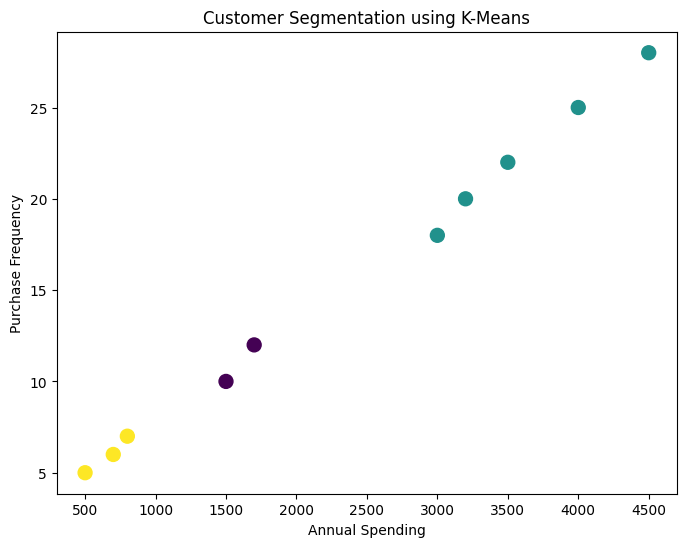

In [5]:
plt.figure(figsize=(8,6))

plt.scatter(
    df['Annual_Spending'],
    df['Purchase_Frequency'],
    c=df['Cluster'],
    cmap='viridis',
    s=100
)

plt.xlabel("Annual Spending")
plt.ylabel("Purchase Frequency")
plt.title("Customer Segmentation using K-Means")

plt.show()

In [6]:
centers = scaler.inverse_transform(kmeans.cluster_centers_)

centers_df = pd.DataFrame(
    centers,
    columns=['Annual_Spending', 'Purchase_Frequency']
)

print(centers_df)

   Annual_Spending  Purchase_Frequency
0      1600.000000                11.0
1      3640.000000                22.6
2       666.666667                 6.0
